# In this notebook, we will be training the dataset in the order from 20k, 30k, 40k, 50k, 60k. We will also generate ROC curve for each loop.

### Initially, I trained the model using 20k dataset, then 40k, then 60k. I found out that the model accuracy was working well. I also found out that the model was not working well for unseen dataset. This seems to be a problem of overfitting. So I am testiing how each model works. 

#### 1. Training 20k dataset, Saving the model as .sav file. (The saved model will later be used for comparision in realtime)

#### 80% of the datasets will be used for training and 20% will be used for testing the dataset

Started 
RF train roc-auc: 1.0
Confusion Matrix :  [[1527  384]
 [  48 2041]]
Precision Score :  0.8416494845360825
Recall Score :  0.9770224988032551
Accuracy Score :  0.892
F1 Score :  0.9042977403633141
RF test ROC AUC=0.934
Time Taken to train and test :  7.832430839538574
------------------------------------------------
Logistic train roc-auc: 0.8934816055127727
Logistic test roc-auc: 0.8878712069575778
Confusion Matrix :  [[1521  390]
 [ 220 1869]]
Precision Score :  0.8273572377158035
Recall Score :  0.8946864528482528
Accuracy Score :  0.8475
F1 Score :  0.859705611775529
Time Taken to train and test :  7.145756959915161
------------------------------------------------
Adaboost train roc-auc: 0.9081695707298316
Adaboost test roc-auc: 0.8943755872566651
Confusion Matrix :  [[1517  394]
 [ 185 1904]]
Precision Score :  0.8285465622280244
Recall Score :  0.9114408808042126
Accuracy Score :  0.85525
F1 Score :  0.8680191474811946
Time Taken to train and test :  3.3366799354553223
-

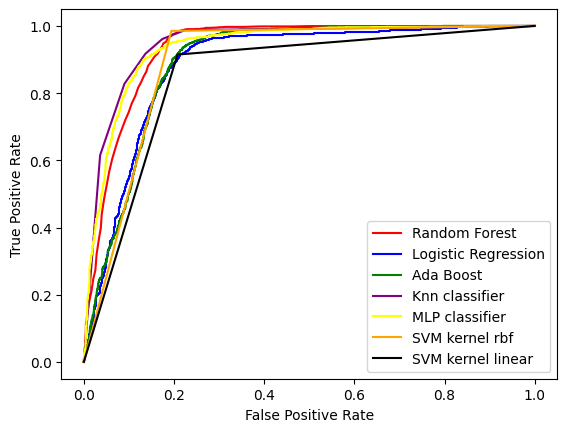

In [8]:
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import time
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
import pickle
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


print("Started ")

folder_name = "trained_model20k"


data = pd.read_csv("../learn_redpitaya/60k_dataframe.csv", header=None)
data = data.sample(frac=1, random_state=42)
X = data.iloc[:20000, 1:] # features
y = data.iloc[:20000, 0] # target variable


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)


start_time = time.time()

## Apply RandomForestClassifier
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
ytrain_pred = rf_model.predict_proba(X_train)
print('RF train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = rf_model.predict_proba(X_test)
# keep probabilities for the positive outcome only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = rf_model.predict(X_test)
rf_conf_matx = confusion_matrix(y_test, y_pred)
rf_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", rf_conf_matx)
print("Precision Score : ", precision_score(y_test, y_pred))
print("Recall Score : ", recall_score(y_test, y_pred))
print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", rf_f1_score)

# summarize scores
print('RF test ROC AUC=%.3f' % (auc_score))
rf_fpr, rf_tpr, thresholds = roc_curve(y_test, ytest_pred)
# Saving the model
file_name = f"{folder_name}/radom_forest_model.sav"
pickle.dump(rf_model, open(file_name, "wb"))

print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")


start_time = time.time()
# Apply Logistic Regression
log_classifier=LogisticRegression(max_iter=40000)
log_classifier.fit(X_train, y_train)
ytrain_pred = log_classifier.predict_proba(X_train)
print('Logistic train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = log_classifier.predict_proba(X_test)
print('Logistic test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = log_classifier.predict(X_test)
log_conf_matx = confusion_matrix(y_test, y_pred)
log_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", log_conf_matx)
print("Precision Score : ", precision_score(y_test, y_pred))
print("Recall Score : ", recall_score(y_test, y_pred))
print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", log_f1_score)
# summarize scores
log_fpr, log_tpr, thresholds2 = roc_curve(y_test, ytest_pred)
# Saving the model
file_name = f"{folder_name}/logistic_model.sav"
pickle.dump(log_classifier, open(file_name, "wb"))

print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")

start_time = time.time()
# Apply Adaboost 
ada_classifier=AdaBoostClassifier()
ada_classifier.fit(X_train, y_train)
ytrain_pred = ada_classifier.predict_proba(X_train)
print('Adaboost train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = ada_classifier.predict_proba(X_test)
print('Adaboost test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
temp = ytest_pred
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = ada_classifier.predict(X_test)
ada_conf_matx = confusion_matrix(y_test, y_pred)
ada_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", ada_conf_matx)
print("Precision Score : ", precision_score(y_test, y_pred))
print("Recall Score : ", recall_score(y_test, y_pred))
print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", ada_f1_score)
# summarize scores
ada_fpr, ada_tpr, thresholds3 = roc_curve(y_test, ytest_pred)
# Saving the model
file_name = f"{folder_name}/ada_boost_model.sav"
pickle.dump(ada_classifier, open(file_name, "wb"))

print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")

start_time = time.time()
# Apply KNN Classifier
knn_classifier=KNeighborsClassifier()
knn_classifier.fit(X_train, y_train)
ytrain_pred = knn_classifier.predict_proba(X_train)
print('KNN train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = knn_classifier.predict_proba(X_test)
print('KNN test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = knn_classifier.predict(X_test)
knn_conf_matx = confusion_matrix(y_test, y_pred)
knn_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", knn_conf_matx)
print("Precision Score : ", precision_score(y_test, y_pred))
print("Recall Score : ", recall_score(y_test, y_pred))
print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", knn_f1_score)
# summarize scores
knn_fpr, knn_tpr, thresholds4 = roc_curve(y_test, ytest_pred)
# Saving the model
file_name = f"{folder_name}/knn_classifier_model.sav"
pickle.dump(knn_classifier, open(file_name, "wb"))

print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")


start_time = time.time()
# Apply Neural Network, Multi Layer Perceptron
mlp = MLPClassifier(hidden_layer_sizes=(128,64,32), activation='relu', solver='adam', max_iter=500)
mlp.fit(X_train,y_train)

ytrain_pred = mlp.predict_proba(X_train)
print('MLP train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = mlp.predict_proba(X_test)
print('MLP test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = mlp.predict(X_test)
mlp_conf_matx = confusion_matrix(y_test, y_pred)
mlp_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", mlp_conf_matx)
print("Precision Score : ", precision_score(y_test, y_pred))
print("Recall Score : ", recall_score(y_test, y_pred))
print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", mlp_f1_score)
# summarize scores
mlp_fpr, mlp_tpr, thresholds5 = roc_curve(y_test, ytest_pred)
# Saving the model
file_name = f"{folder_name}/mlp_model.sav"
pickle.dump(mlp, open(file_name, "wb"))


print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")


start_time = time.time()
# Apply Support Vector Machine Classifier
svm_clf = make_pipeline(StandardScaler(), SVC(gamma='auto'))
svm_clf.fit(X_train,y_train)

#Confusion Matrix
y_pred = svm_clf.predict(X_test)
svm_conf_matx = confusion_matrix(y_test, y_pred)
svm_f1_score = f1_score(y_test, y_pred)
print("SVM with RBF kernel")
print("Confusion Matrix : ", svm_conf_matx)
print("Precision Score : ", precision_score(y_test, y_pred))
print("Recall Score : ", recall_score(y_test, y_pred))
print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", svm_f1_score)
# summarize scores
svm_fpr, svm_tpr, thresholds6 = roc_curve(y_test, y_pred)
# Saving the model
file_name = f"{folder_name}/svm_kernel_rbf.sav"
pickle.dump(svm_clf, open(file_name, "wb"))


print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")


start_time = time.time()
# Apply Support Vector Machine Classifier Kernel Linear
svm_lin_clf = make_pipeline(StandardScaler(), SVC(kernel="linear"))
svm_lin_clf.fit(X_train,y_train)

#Confusion Matrix
y_pred = svm_lin_clf.predict(X_test)
svm_lin_conf_matx = confusion_matrix(y_test, y_pred)
svm_lin_f1_score = f1_score(y_test, y_pred)
print("SVM with linear kernel")
print("Confusion Matrix : ", svm_lin_conf_matx)
print("Precision Score : ", precision_score(y_test, y_pred))
print("Recall Score : ", recall_score(y_test, y_pred))
print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", svm_lin_f1_score)
# summarize scores
svm_lin_fpr, svm_lin_tpr, thresholds6 = roc_curve(y_test, y_pred)
# Saving the model
file_name = f"{folder_name}/svm_kernel_linear.sav"
pickle.dump(svm_lin_clf, open(file_name, "wb"))


print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")


# plot the roc curve for the model
pyplot.plot(rf_fpr, rf_tpr, color="red", label='Random Forest')
pyplot.plot(log_fpr, log_tpr, color="blue", label='Logistic Regression')
pyplot.plot(ada_fpr, ada_tpr, color="green", label='Ada Boost')
pyplot.plot(knn_fpr, knn_tpr, color="purple", label='Knn classifier')
pyplot.plot(mlp_fpr, mlp_tpr, color="yellow", label='MLP classifier')
pyplot.plot(svm_fpr, svm_tpr, color="orange", label='SVM kernel rbf')
pyplot.plot(svm_lin_fpr, svm_lin_tpr, color="black", label='SVM kernel linear ')

# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()
#save the image
pyplot.savefig(f'{folder_name}/roc_auc_curve.svg', format='svg')
# show the plot
pyplot.show()

### 2. Training the dataset on 30k dataset

Started 
RF train roc-auc: 1.0
Confusion Matrix :  [[2277  538]
 [  69 3116]]
Precision Score :  0.8527640941434045
Recall Score :  0.9783359497645212
Accuracy Score :  0.8988333333333334
F1 Score :  0.9112443339669541
RF test ROC AUC=0.944
Time Taken to train and test :  12.607128858566284
------------------------------------------------
Logistic train roc-auc: 0.8945042388045537
Logistic test roc-auc: 0.892855107338741
Confusion Matrix :  [[2299  516]
 [ 363 2822]]
Precision Score :  0.8454164170161773
Recall Score :  0.8860282574568289
Accuracy Score :  0.8535
F1 Score :  0.8652460524298636
Time Taken to train and test :  6.19865608215332
------------------------------------------------
Adaboost train roc-auc: 0.9062935275094051
Adaboost test roc-auc: 0.9019364193279442
Confusion Matrix :  [[2251  564]
 [ 278 2907]]
Precision Score :  0.8375108038029386
Recall Score :  0.9127158555729984
Accuracy Score :  0.8596666666666667
F1 Score :  0.8734975961538461
Time Taken to train and test

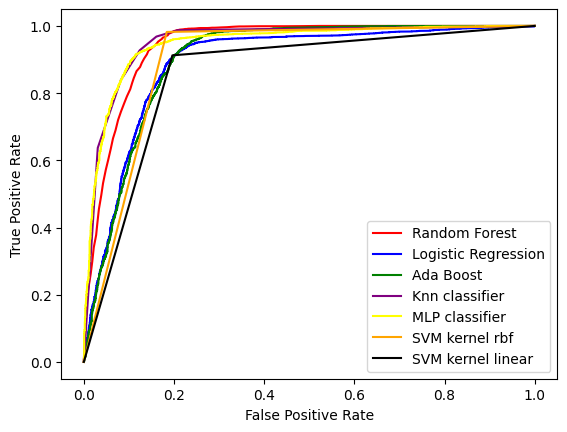

In [9]:
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import time
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
import pickle
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


print("Started ")

folder_name = "trained_model30k"


data = pd.read_csv("../learn_redpitaya/60k_dataframe.csv", header=None)
data = data.sample(frac=1, random_state=42)
X = data.iloc[:30000, 1:] # features
y = data.iloc[:30000, 0] # target variable


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)


start_time = time.time()

## Apply RandomForestClassifier
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
ytrain_pred = rf_model.predict_proba(X_train)
print('RF train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = rf_model.predict_proba(X_test)
# keep probabilities for the positive outcome only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = rf_model.predict(X_test)
rf_conf_matx = confusion_matrix(y_test, y_pred)
rf_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", rf_conf_matx)
print("Precision Score : ", precision_score(y_test, y_pred))
print("Recall Score : ", recall_score(y_test, y_pred))
print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", rf_f1_score)

# summarize scores
print('RF test ROC AUC=%.3f' % (auc_score))
rf_fpr, rf_tpr, thresholds = roc_curve(y_test, ytest_pred)
# Saving the model
file_name = f"{folder_name}/radom_forest_model.sav"
pickle.dump(rf_model, open(file_name, "wb"))

print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")


start_time = time.time()
# Apply Logistic Regression
log_classifier=LogisticRegression(max_iter=40000)
log_classifier.fit(X_train, y_train)
ytrain_pred = log_classifier.predict_proba(X_train)
print('Logistic train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = log_classifier.predict_proba(X_test)
print('Logistic test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = log_classifier.predict(X_test)
log_conf_matx = confusion_matrix(y_test, y_pred)
log_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", log_conf_matx)
print("Precision Score : ", precision_score(y_test, y_pred))
print("Recall Score : ", recall_score(y_test, y_pred))
print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", log_f1_score)
# summarize scores
log_fpr, log_tpr, thresholds2 = roc_curve(y_test, ytest_pred)
# Saving the model
file_name = f"{folder_name}/logistic_model.sav"
pickle.dump(log_classifier, open(file_name, "wb"))

print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")

start_time = time.time()
# Apply Adaboost 
ada_classifier=AdaBoostClassifier()
ada_classifier.fit(X_train, y_train)
ytrain_pred = ada_classifier.predict_proba(X_train)
print('Adaboost train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = ada_classifier.predict_proba(X_test)
print('Adaboost test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
temp = ytest_pred
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = ada_classifier.predict(X_test)
ada_conf_matx = confusion_matrix(y_test, y_pred)
ada_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", ada_conf_matx)
print("Precision Score : ", precision_score(y_test, y_pred))
print("Recall Score : ", recall_score(y_test, y_pred))
print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", ada_f1_score)
# summarize scores
ada_fpr, ada_tpr, thresholds3 = roc_curve(y_test, ytest_pred)
# Saving the model
file_name = f"{folder_name}/ada_boost_model.sav"
pickle.dump(ada_classifier, open(file_name, "wb"))

print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")

start_time = time.time()
# Apply KNN Classifier
knn_classifier=KNeighborsClassifier()
knn_classifier.fit(X_train, y_train)
ytrain_pred = knn_classifier.predict_proba(X_train)
print('KNN train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = knn_classifier.predict_proba(X_test)
print('KNN test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = knn_classifier.predict(X_test)
knn_conf_matx = confusion_matrix(y_test, y_pred)
knn_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", knn_conf_matx)
print("Precision Score : ", precision_score(y_test, y_pred))
print("Recall Score : ", recall_score(y_test, y_pred))
print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", knn_f1_score)
# summarize scores
knn_fpr, knn_tpr, thresholds4 = roc_curve(y_test, ytest_pred)
# Saving the model
file_name = f"{folder_name}/knn_classifier_model.sav"
pickle.dump(knn_classifier, open(file_name, "wb"))

print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")


start_time = time.time()
# Apply Neural Network, Multi Layer Perceptron
mlp = MLPClassifier(hidden_layer_sizes=(128,64,32), activation='relu', solver='adam', max_iter=500)
mlp.fit(X_train,y_train)

ytrain_pred = mlp.predict_proba(X_train)
print('MLP train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = mlp.predict_proba(X_test)
print('MLP test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = mlp.predict(X_test)
mlp_conf_matx = confusion_matrix(y_test, y_pred)
mlp_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", mlp_conf_matx)
print("Precision Score : ", precision_score(y_test, y_pred))
print("Recall Score : ", recall_score(y_test, y_pred))
print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", mlp_f1_score)
# summarize scores
mlp_fpr, mlp_tpr, thresholds5 = roc_curve(y_test, ytest_pred)
# Saving the model
file_name = f"{folder_name}/mlp_model.sav"
pickle.dump(mlp, open(file_name, "wb"))


print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")


start_time = time.time()
# Apply Support Vector Machine Classifier
svm_clf = make_pipeline(StandardScaler(), SVC(gamma='auto'))
svm_clf.fit(X_train,y_train)

#Confusion Matrix
y_pred = svm_clf.predict(X_test)
svm_conf_matx = confusion_matrix(y_test, y_pred)
svm_f1_score = f1_score(y_test, y_pred)
print("SVM with RBF kernel")
print("Confusion Matrix : ", svm_conf_matx)
print("Precision Score : ", precision_score(y_test, y_pred))
print("Recall Score : ", recall_score(y_test, y_pred))
print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", svm_f1_score)
# summarize scores
svm_fpr, svm_tpr, thresholds6 = roc_curve(y_test, y_pred)
# Saving the model
file_name = f"{folder_name}/svm_kernel_rbf.sav"
pickle.dump(svm_clf, open(file_name, "wb"))


print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")


start_time = time.time()
# Apply Support Vector Machine Classifier Kernel Linear
svm_lin_clf = make_pipeline(StandardScaler(), SVC(kernel="linear"))
svm_lin_clf.fit(X_train,y_train)

#Confusion Matrix
y_pred = svm_lin_clf.predict(X_test)
svm_lin_conf_matx = confusion_matrix(y_test, y_pred)
svm_lin_f1_score = f1_score(y_test, y_pred)
print("SVM with linear kernel")
print("Confusion Matrix : ", svm_lin_conf_matx)
print("Precision Score : ", precision_score(y_test, y_pred))
print("Recall Score : ", recall_score(y_test, y_pred))
print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", svm_lin_f1_score)
# summarize scores
svm_lin_fpr, svm_lin_tpr, thresholds6 = roc_curve(y_test, y_pred)
# Saving the model
file_name = f"{folder_name}/svm_kernel_linear.sav"
pickle.dump(svm_lin_clf, open(file_name, "wb"))


print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")


# plot the roc curve for the model
pyplot.plot(rf_fpr, rf_tpr, color="red", label='Random Forest')
pyplot.plot(log_fpr, log_tpr, color="blue", label='Logistic Regression')
pyplot.plot(ada_fpr, ada_tpr, color="green", label='Ada Boost')
pyplot.plot(knn_fpr, knn_tpr, color="purple", label='Knn classifier')
pyplot.plot(mlp_fpr, mlp_tpr, color="yellow", label='MLP classifier')
pyplot.plot(svm_fpr, svm_tpr, color="orange", label='SVM kernel rbf')
pyplot.plot(svm_lin_fpr, svm_lin_tpr, color="black", label='SVM kernel linear ')

# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()
#save the image
pyplot.savefig(f'{folder_name}/roc_auc_curve.svg', format='svg')
# show the plot
pyplot.show()

### 3. Testing with 40k dataset

Started 
RF train roc-auc: 1.0
Confusion Matrix :  [[3012  741]
 [  84 4163]]
Precision Score :  0.8488988580750407
Recall Score :  0.9802213327054391
Accuracy Score :  0.896875
F1 Score :  0.9098459184788547
RF test ROC AUC=0.948
Time Taken to train and test :  17.51991081237793
------------------------------------------------
Logistic train roc-auc: 0.895965294325915
Logistic test roc-auc: 0.8911712165468944
Confusion Matrix :  [[3035  718]
 [ 442 3805]]
Precision Score :  0.8412558036701304
Recall Score :  0.8959265363786202
Accuracy Score :  0.855
F1 Score :  0.8677309007981755
Time Taken to train and test :  7.958967208862305
------------------------------------------------
Adaboost train roc-auc: 0.907820142237094
Adaboost test roc-auc: 0.8994289851848214
Confusion Matrix :  [[2986  767]
 [ 371 3876]]
Precision Score :  0.8348050829205256
Recall Score :  0.9126442194490229
Accuracy Score :  0.85775
F1 Score :  0.8719910011248593
Time Taken to train and test :  6.248460054397583
-

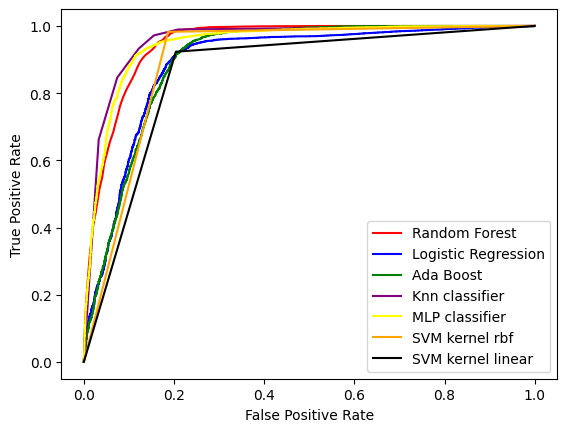

In [10]:
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import time
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
import pickle
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


print("Started ")

folder_name = "trained_model40k"


data = pd.read_csv("../learn_redpitaya/60k_dataframe.csv", header=None)
data = data.sample(frac=1, random_state=42)
X = data.iloc[:40000, 1:] # features
y = data.iloc[:40000, 0] # target variable


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)


start_time = time.time()

## Apply RandomForestClassifier
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
ytrain_pred = rf_model.predict_proba(X_train)
print('RF train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = rf_model.predict_proba(X_test)
# keep probabilities for the positive outcome only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = rf_model.predict(X_test)
rf_conf_matx = confusion_matrix(y_test, y_pred)
rf_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", rf_conf_matx)
print("Precision Score : ", precision_score(y_test, y_pred))
print("Recall Score : ", recall_score(y_test, y_pred))
print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", rf_f1_score)

# summarize scores
print('RF test ROC AUC=%.3f' % (auc_score))
rf_fpr, rf_tpr, thresholds = roc_curve(y_test, ytest_pred)
# Saving the model
file_name = f"{folder_name}/radom_forest_model.sav"
pickle.dump(rf_model, open(file_name, "wb"))

print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")


start_time = time.time()
# Apply Logistic Regression
log_classifier=LogisticRegression(max_iter=40000)
log_classifier.fit(X_train, y_train)
ytrain_pred = log_classifier.predict_proba(X_train)
print('Logistic train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = log_classifier.predict_proba(X_test)
print('Logistic test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = log_classifier.predict(X_test)
log_conf_matx = confusion_matrix(y_test, y_pred)
log_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", log_conf_matx)
print("Precision Score : ", precision_score(y_test, y_pred))
print("Recall Score : ", recall_score(y_test, y_pred))
print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", log_f1_score)
# summarize scores
log_fpr, log_tpr, thresholds2 = roc_curve(y_test, ytest_pred)
# Saving the model
file_name = f"{folder_name}/logistic_model.sav"
pickle.dump(log_classifier, open(file_name, "wb"))

print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")

start_time = time.time()
# Apply Adaboost 
ada_classifier=AdaBoostClassifier()
ada_classifier.fit(X_train, y_train)
ytrain_pred = ada_classifier.predict_proba(X_train)
print('Adaboost train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = ada_classifier.predict_proba(X_test)
print('Adaboost test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
temp = ytest_pred
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = ada_classifier.predict(X_test)
ada_conf_matx = confusion_matrix(y_test, y_pred)
ada_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", ada_conf_matx)
print("Precision Score : ", precision_score(y_test, y_pred))
print("Recall Score : ", recall_score(y_test, y_pred))
print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", ada_f1_score)
# summarize scores
ada_fpr, ada_tpr, thresholds3 = roc_curve(y_test, ytest_pred)
# Saving the model
file_name = f"{folder_name}/ada_boost_model.sav"
pickle.dump(ada_classifier, open(file_name, "wb"))

print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")

start_time = time.time()
# Apply KNN Classifier
knn_classifier=KNeighborsClassifier()
knn_classifier.fit(X_train, y_train)
ytrain_pred = knn_classifier.predict_proba(X_train)
print('KNN train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = knn_classifier.predict_proba(X_test)
print('KNN test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = knn_classifier.predict(X_test)
knn_conf_matx = confusion_matrix(y_test, y_pred)
knn_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", knn_conf_matx)
print("Precision Score : ", precision_score(y_test, y_pred))
print("Recall Score : ", recall_score(y_test, y_pred))
print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", knn_f1_score)
# summarize scores
knn_fpr, knn_tpr, thresholds4 = roc_curve(y_test, ytest_pred)
# Saving the model
file_name = f"{folder_name}/knn_classifier_model.sav"
pickle.dump(knn_classifier, open(file_name, "wb"))

print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")


start_time = time.time()
# Apply Neural Network, Multi Layer Perceptron
mlp = MLPClassifier(hidden_layer_sizes=(128,64,32), activation='relu', solver='adam', max_iter=500)
mlp.fit(X_train,y_train)

ytrain_pred = mlp.predict_proba(X_train)
print('MLP train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = mlp.predict_proba(X_test)
print('MLP test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = mlp.predict(X_test)
mlp_conf_matx = confusion_matrix(y_test, y_pred)
mlp_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", mlp_conf_matx)
print("Precision Score : ", precision_score(y_test, y_pred))
print("Recall Score : ", recall_score(y_test, y_pred))
print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", mlp_f1_score)
# summarize scores
mlp_fpr, mlp_tpr, thresholds5 = roc_curve(y_test, ytest_pred)
# Saving the model
file_name = f"{folder_name}/mlp_model.sav"
pickle.dump(mlp, open(file_name, "wb"))


print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")


start_time = time.time()
# Apply Support Vector Machine Classifier
svm_clf = make_pipeline(StandardScaler(), SVC(gamma='auto'))
svm_clf.fit(X_train,y_train)

#Confusion Matrix
y_pred = svm_clf.predict(X_test)
svm_conf_matx = confusion_matrix(y_test, y_pred)
svm_f1_score = f1_score(y_test, y_pred)
print("SVM with RBF kernel")
print("Confusion Matrix : ", svm_conf_matx)
print("Precision Score : ", precision_score(y_test, y_pred))
print("Recall Score : ", recall_score(y_test, y_pred))
print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", svm_f1_score)
# summarize scores
svm_fpr, svm_tpr, thresholds6 = roc_curve(y_test, y_pred)
# Saving the model
file_name = f"{folder_name}/svm_kernel_rbf.sav"
pickle.dump(svm_clf, open(file_name, "wb"))


print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")


start_time = time.time()
# Apply Support Vector Machine Classifier Kernel Linear
svm_lin_clf = make_pipeline(StandardScaler(), SVC(kernel="linear"))
svm_lin_clf.fit(X_train,y_train)

#Confusion Matrix
y_pred = svm_lin_clf.predict(X_test)
svm_lin_conf_matx = confusion_matrix(y_test, y_pred)
svm_lin_f1_score = f1_score(y_test, y_pred)
print("SVM with linear kernel")
print("Confusion Matrix : ", svm_lin_conf_matx)
print("Precision Score : ", precision_score(y_test, y_pred))
print("Recall Score : ", recall_score(y_test, y_pred))
print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", svm_lin_f1_score)
# summarize scores
svm_lin_fpr, svm_lin_tpr, thresholds6 = roc_curve(y_test, y_pred)
# Saving the model
file_name = f"{folder_name}/svm_kernel_linear.sav"
pickle.dump(svm_lin_clf, open(file_name, "wb"))


print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")


# plot the roc curve for the model
pyplot.plot(rf_fpr, rf_tpr, color="red", label='Random Forest')
pyplot.plot(log_fpr, log_tpr, color="blue", label='Logistic Regression')
pyplot.plot(ada_fpr, ada_tpr, color="green", label='Ada Boost')
pyplot.plot(knn_fpr, knn_tpr, color="purple", label='Knn classifier')
pyplot.plot(mlp_fpr, mlp_tpr, color="yellow", label='MLP classifier')
pyplot.plot(svm_fpr, svm_tpr, color="orange", label='SVM kernel rbf')
pyplot.plot(svm_lin_fpr, svm_lin_tpr, color="black", label='SVM kernel linear ')

# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()
#save the image
pyplot.savefig(f'{folder_name}/roc_auc_curve.svg', format='svg')
# show the plot
pyplot.show()

### 4. Training on 50k dataset

Started 
RF train roc-auc: 1.0
Confusion Matrix :  [[3834  908]
 [ 103 5155]]
Precision Score :  0.8502391555335642
Recall Score :  0.9804108025865348
Accuracy Score :  0.8989
F1 Score :  0.9106969348997438
RF test ROC AUC=0.951
Time Taken to train and test :  22.86531090736389
------------------------------------------------
Logistic train roc-auc: 0.8955104538215021
Logistic test roc-auc: 0.8932240626602768
Confusion Matrix :  [[3848  894]
 [ 554 4704]]
Precision Score :  0.8403001071811361
Recall Score :  0.894636744009129
Accuracy Score :  0.8552
F1 Score :  0.866617538688283
Time Taken to train and test :  25.816158771514893
------------------------------------------------
Adaboost train roc-auc: 0.9060928789766747
Adaboost test roc-auc: 0.901919615090355
Confusion Matrix :  [[3760  982]
 [ 439 4819]]
Precision Score :  0.8307188415790381
Recall Score :  0.9165081780144542
Accuracy Score :  0.8579
F1 Score :  0.8715073695632516
Time Taken to train and test :  7.823686838150024
---

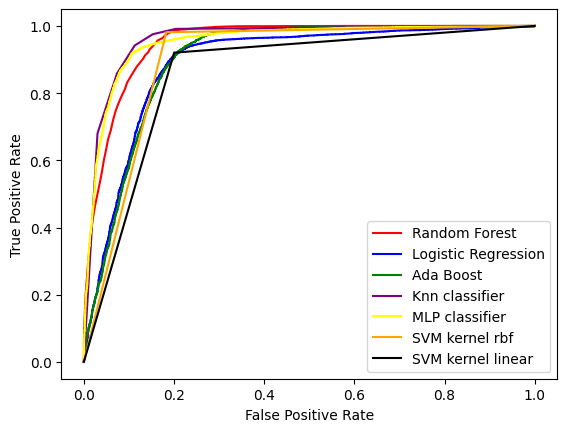

In [11]:
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import time
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
import pickle
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


print("Started ")

folder_name = "trained_model50k"


data = pd.read_csv("../learn_redpitaya/60k_dataframe.csv", header=None)
data = data.sample(frac=1, random_state=42)
X = data.iloc[:50000, 1:] # features
y = data.iloc[:50000, 0] # target variable


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)


start_time = time.time()

## Apply RandomForestClassifier
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
ytrain_pred = rf_model.predict_proba(X_train)
print('RF train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = rf_model.predict_proba(X_test)
# keep probabilities for the positive outcome only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = rf_model.predict(X_test)
rf_conf_matx = confusion_matrix(y_test, y_pred)
rf_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", rf_conf_matx)
print("Precision Score : ", precision_score(y_test, y_pred))
print("Recall Score : ", recall_score(y_test, y_pred))
print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", rf_f1_score)

# summarize scores
print('RF test ROC AUC=%.3f' % (auc_score))
rf_fpr, rf_tpr, thresholds = roc_curve(y_test, ytest_pred)
# Saving the model
file_name = f"{folder_name}/radom_forest_model.sav"
pickle.dump(rf_model, open(file_name, "wb"))

print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")


start_time = time.time()
# Apply Logistic Regression
log_classifier=LogisticRegression(max_iter=40000)
log_classifier.fit(X_train, y_train)
ytrain_pred = log_classifier.predict_proba(X_train)
print('Logistic train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = log_classifier.predict_proba(X_test)
print('Logistic test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = log_classifier.predict(X_test)
log_conf_matx = confusion_matrix(y_test, y_pred)
log_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", log_conf_matx)
print("Precision Score : ", precision_score(y_test, y_pred))
print("Recall Score : ", recall_score(y_test, y_pred))
print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", log_f1_score)
# summarize scores
log_fpr, log_tpr, thresholds2 = roc_curve(y_test, ytest_pred)
# Saving the model
file_name = f"{folder_name}/logistic_model.sav"
pickle.dump(log_classifier, open(file_name, "wb"))

print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")

start_time = time.time()
# Apply Adaboost 
ada_classifier=AdaBoostClassifier()
ada_classifier.fit(X_train, y_train)
ytrain_pred = ada_classifier.predict_proba(X_train)
print('Adaboost train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = ada_classifier.predict_proba(X_test)
print('Adaboost test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
temp = ytest_pred
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = ada_classifier.predict(X_test)
ada_conf_matx = confusion_matrix(y_test, y_pred)
ada_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", ada_conf_matx)
print("Precision Score : ", precision_score(y_test, y_pred))
print("Recall Score : ", recall_score(y_test, y_pred))
print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", ada_f1_score)
# summarize scores
ada_fpr, ada_tpr, thresholds3 = roc_curve(y_test, ytest_pred)
# Saving the model
file_name = f"{folder_name}/ada_boost_model.sav"
pickle.dump(ada_classifier, open(file_name, "wb"))

print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")

start_time = time.time()
# Apply KNN Classifier
knn_classifier=KNeighborsClassifier()
knn_classifier.fit(X_train, y_train)
ytrain_pred = knn_classifier.predict_proba(X_train)
print('KNN train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = knn_classifier.predict_proba(X_test)
print('KNN test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = knn_classifier.predict(X_test)
knn_conf_matx = confusion_matrix(y_test, y_pred)
knn_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", knn_conf_matx)
print("Precision Score : ", precision_score(y_test, y_pred))
print("Recall Score : ", recall_score(y_test, y_pred))
print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", knn_f1_score)
# summarize scores
knn_fpr, knn_tpr, thresholds4 = roc_curve(y_test, ytest_pred)
# Saving the model
file_name = f"{folder_name}/knn_classifier_model.sav"
pickle.dump(knn_classifier, open(file_name, "wb"))

print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")


start_time = time.time()
# Apply Neural Network, Multi Layer Perceptron
mlp = MLPClassifier(hidden_layer_sizes=(128,64,32), activation='relu', solver='adam', max_iter=500)
mlp.fit(X_train,y_train)

ytrain_pred = mlp.predict_proba(X_train)
print('MLP train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = mlp.predict_proba(X_test)
print('MLP test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = mlp.predict(X_test)
mlp_conf_matx = confusion_matrix(y_test, y_pred)
mlp_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", mlp_conf_matx)
print("Precision Score : ", precision_score(y_test, y_pred))
print("Recall Score : ", recall_score(y_test, y_pred))
print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", mlp_f1_score)
# summarize scores
mlp_fpr, mlp_tpr, thresholds5 = roc_curve(y_test, ytest_pred)
# Saving the model
file_name = f"{folder_name}/mlp_model.sav"
pickle.dump(mlp, open(file_name, "wb"))


print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")


start_time = time.time()
# Apply Support Vector Machine Classifier
svm_clf = make_pipeline(StandardScaler(), SVC(gamma='auto'))
svm_clf.fit(X_train,y_train)

#Confusion Matrix
y_pred = svm_clf.predict(X_test)
svm_conf_matx = confusion_matrix(y_test, y_pred)
svm_f1_score = f1_score(y_test, y_pred)
print("SVM with RBF kernel")
print("Confusion Matrix : ", svm_conf_matx)
print("Precision Score : ", precision_score(y_test, y_pred))
print("Recall Score : ", recall_score(y_test, y_pred))
print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", svm_f1_score)
# summarize scores
svm_fpr, svm_tpr, thresholds6 = roc_curve(y_test, y_pred)
# Saving the model
file_name = f"{folder_name}/svm_kernel_rbf.sav"
pickle.dump(svm_clf, open(file_name, "wb"))


print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")


start_time = time.time()
# Apply Support Vector Machine Classifier Kernel Linear
svm_lin_clf = make_pipeline(StandardScaler(), SVC(kernel="linear"))
svm_lin_clf.fit(X_train,y_train)

#Confusion Matrix
y_pred = svm_lin_clf.predict(X_test)
svm_lin_conf_matx = confusion_matrix(y_test, y_pred)
svm_lin_f1_score = f1_score(y_test, y_pred)
print("SVM with linear kernel")
print("Confusion Matrix : ", svm_lin_conf_matx)
print("Precision Score : ", precision_score(y_test, y_pred))
print("Recall Score : ", recall_score(y_test, y_pred))
print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", svm_lin_f1_score)
# summarize scores
svm_lin_fpr, svm_lin_tpr, thresholds6 = roc_curve(y_test, y_pred)
# Saving the model
file_name = f"{folder_name}/svm_kernel_linear.sav"
pickle.dump(svm_lin_clf, open(file_name, "wb"))


print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")


# plot the roc curve for the model
pyplot.plot(rf_fpr, rf_tpr, color="red", label='Random Forest')
pyplot.plot(log_fpr, log_tpr, color="blue", label='Logistic Regression')
pyplot.plot(ada_fpr, ada_tpr, color="green", label='Ada Boost')
pyplot.plot(knn_fpr, knn_tpr, color="purple", label='Knn classifier')
pyplot.plot(mlp_fpr, mlp_tpr, color="yellow", label='MLP classifier')
pyplot.plot(svm_fpr, svm_tpr, color="orange", label='SVM kernel rbf')
pyplot.plot(svm_lin_fpr, svm_lin_tpr, color="black", label='SVM kernel linear ')

# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()
#save the image
pyplot.savefig(f'{folder_name}/roc_auc_curve.svg', format='svg')
# show the plot
pyplot.show()

### 5. Training on 60k dataset

Started 
RF train roc-auc: 1.0
Confusion Matrix :  [[4479 1025]
 [  99 5815]]
Precision Score :  0.8501461988304093
Recall Score :  0.983260060872506
Accuracy Score :  0.9015589420213698
F1 Score :  0.9118707856358789
RF test ROC AUC=0.953
Time Taken to train and test :  26.950076818466187
------------------------------------------------
Logistic train roc-auc: 0.8948018450813489
Logistic test roc-auc: 0.8950776598788056
Confusion Matrix :  [[4450 1054]
 [ 603 5311]]
Precision Score :  0.834406912804399
Recall Score :  0.8980385525870815
Accuracy Score :  0.8548782623927133
F1 Score :  0.8650541575046827
Time Taken to train and test :  20.571735858917236
------------------------------------------------
Adaboost train roc-auc: 0.9067233870664081
Adaboost test roc-auc: 0.9046480814395875
Confusion Matrix :  [[4396 1108]
 [ 476 5438]]
Precision Score :  0.8307363275282615
Recall Score :  0.9195130199526547
Accuracy Score :  0.861271676300578
F1 Score :  0.8728731942215088
Time Taken to tr

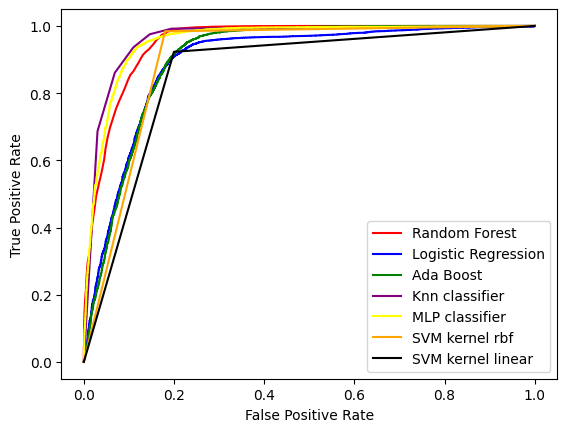

In [12]:
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import time
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
import pickle
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


print("Started ")

folder_name = "trained_model60k"


data = pd.read_csv("../learn_redpitaya/60k_dataframe.csv", header=None)
data = data.sample(frac=1, random_state=42)
X = data.iloc[:, 1:] # features
y = data.iloc[:, 0] # target variable


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)


start_time = time.time()

## Apply RandomForestClassifier
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
ytrain_pred = rf_model.predict_proba(X_train)
print('RF train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = rf_model.predict_proba(X_test)
# keep probabilities for the positive outcome only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = rf_model.predict(X_test)
rf_conf_matx = confusion_matrix(y_test, y_pred)
rf_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", rf_conf_matx)
print("Precision Score : ", precision_score(y_test, y_pred))
print("Recall Score : ", recall_score(y_test, y_pred))
print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", rf_f1_score)

# summarize scores
print('RF test ROC AUC=%.3f' % (auc_score))
rf_fpr, rf_tpr, thresholds = roc_curve(y_test, ytest_pred)
# Saving the model
file_name = f"{folder_name}/radom_forest_model.sav"
pickle.dump(rf_model, open(file_name, "wb"))

print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")


start_time = time.time()
# Apply Logistic Regression
log_classifier=LogisticRegression(max_iter=40000)
log_classifier.fit(X_train, y_train)
ytrain_pred = log_classifier.predict_proba(X_train)
print('Logistic train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = log_classifier.predict_proba(X_test)
print('Logistic test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = log_classifier.predict(X_test)
log_conf_matx = confusion_matrix(y_test, y_pred)
log_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", log_conf_matx)
print("Precision Score : ", precision_score(y_test, y_pred))
print("Recall Score : ", recall_score(y_test, y_pred))
print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", log_f1_score)
# summarize scores
log_fpr, log_tpr, thresholds2 = roc_curve(y_test, ytest_pred)
# Saving the model
file_name = f"{folder_name}/logistic_model.sav"
pickle.dump(log_classifier, open(file_name, "wb"))

print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")

start_time = time.time()
# Apply Adaboost 
ada_classifier=AdaBoostClassifier()
ada_classifier.fit(X_train, y_train)
ytrain_pred = ada_classifier.predict_proba(X_train)
print('Adaboost train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = ada_classifier.predict_proba(X_test)
print('Adaboost test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
temp = ytest_pred
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = ada_classifier.predict(X_test)
ada_conf_matx = confusion_matrix(y_test, y_pred)
ada_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", ada_conf_matx)
print("Precision Score : ", precision_score(y_test, y_pred))
print("Recall Score : ", recall_score(y_test, y_pred))
print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", ada_f1_score)
# summarize scores
ada_fpr, ada_tpr, thresholds3 = roc_curve(y_test, ytest_pred)
# Saving the model
file_name = f"{folder_name}/ada_boost_model.sav"
pickle.dump(ada_classifier, open(file_name, "wb"))

print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")

start_time = time.time()
# Apply KNN Classifier
knn_classifier=KNeighborsClassifier()
knn_classifier.fit(X_train, y_train)
ytrain_pred = knn_classifier.predict_proba(X_train)
print('KNN train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = knn_classifier.predict_proba(X_test)
print('KNN test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = knn_classifier.predict(X_test)
knn_conf_matx = confusion_matrix(y_test, y_pred)
knn_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", knn_conf_matx)
print("Precision Score : ", precision_score(y_test, y_pred))
print("Recall Score : ", recall_score(y_test, y_pred))
print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", knn_f1_score)
# summarize scores
knn_fpr, knn_tpr, thresholds4 = roc_curve(y_test, ytest_pred)
# Saving the model
file_name = f"{folder_name}/knn_classifier_model.sav"
pickle.dump(knn_classifier, open(file_name, "wb"))

print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")


start_time = time.time()
# Apply Neural Network, Multi Layer Perceptron
mlp = MLPClassifier(hidden_layer_sizes=(128,64,32), activation='relu', solver='adam', max_iter=500)
mlp.fit(X_train,y_train)

ytrain_pred = mlp.predict_proba(X_train)
print('MLP train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = mlp.predict_proba(X_test)
print('MLP test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = mlp.predict(X_test)
mlp_conf_matx = confusion_matrix(y_test, y_pred)
mlp_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", mlp_conf_matx)
print("Precision Score : ", precision_score(y_test, y_pred))
print("Recall Score : ", recall_score(y_test, y_pred))
print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", mlp_f1_score)
# summarize scores
mlp_fpr, mlp_tpr, thresholds5 = roc_curve(y_test, ytest_pred)
# Saving the model
file_name = f"{folder_name}/mlp_model.sav"
pickle.dump(mlp, open(file_name, "wb"))


print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")


start_time = time.time()
# Apply Support Vector Machine Classifier
svm_clf = make_pipeline(StandardScaler(), SVC(gamma='auto'))
svm_clf.fit(X_train,y_train)

#Confusion Matrix
y_pred = svm_clf.predict(X_test)
svm_conf_matx = confusion_matrix(y_test, y_pred)
svm_f1_score = f1_score(y_test, y_pred)
print("SVM with RBF kernel")
print("Confusion Matrix : ", svm_conf_matx)
print("Precision Score : ", precision_score(y_test, y_pred))
print("Recall Score : ", recall_score(y_test, y_pred))
print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", svm_f1_score)
# summarize scores
svm_fpr, svm_tpr, thresholds6 = roc_curve(y_test, y_pred)
# Saving the model
file_name = f"{folder_name}/svm_kernel_rbf.sav"
pickle.dump(svm_clf, open(file_name, "wb"))


print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")


start_time = time.time()
# Apply Support Vector Machine Classifier Kernel Linear
svm_lin_clf = make_pipeline(StandardScaler(), SVC(kernel="linear"))
svm_lin_clf.fit(X_train,y_train)

#Confusion Matrix
y_pred = svm_lin_clf.predict(X_test)
svm_lin_conf_matx = confusion_matrix(y_test, y_pred)
svm_lin_f1_score = f1_score(y_test, y_pred)
print("SVM with linear kernel")
print("Confusion Matrix : ", svm_lin_conf_matx)
print("Precision Score : ", precision_score(y_test, y_pred))
print("Recall Score : ", recall_score(y_test, y_pred))
print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", svm_lin_f1_score)
# summarize scores
svm_lin_fpr, svm_lin_tpr, thresholds6 = roc_curve(y_test, y_pred)
# Saving the model
file_name = f"{folder_name}/svm_kernel_linear.sav"
pickle.dump(svm_lin_clf, open(file_name, "wb"))


print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")


# plot the roc curve for the model
pyplot.plot(rf_fpr, rf_tpr, color="red", label='Random Forest')
pyplot.plot(log_fpr, log_tpr, color="blue", label='Logistic Regression')
pyplot.plot(ada_fpr, ada_tpr, color="green", label='Ada Boost')
pyplot.plot(knn_fpr, knn_tpr, color="purple", label='Knn classifier')
pyplot.plot(mlp_fpr, mlp_tpr, color="yellow", label='MLP classifier')
pyplot.plot(svm_fpr, svm_tpr, color="orange", label='SVM kernel rbf')
pyplot.plot(svm_lin_fpr, svm_lin_tpr, color="black", label='SVM kernel linear ')

# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()
#save the image
pyplot.savefig(f'{folder_name}/roc_auc_curve.svg', format='svg')
# show the plot
pyplot.show()

# Comparing the saved model using the new collected dataset

## Step 1. Creating a CSV file from the experiments result folder

In [13]:
import pandas as pd
import os, glob
import time
import numpy as np
import struct

begining_start_time = time.time()

folder_locations = [ "../../../Desktop/experiments_nine_2203/", ]


final_dataframe = pd.DataFrame()

for folder in folder_locations:
    start_time = time.time()
    path = folder + "binaries/"
    
    intermediate_df = pd.DataFrame()
    
    for filename in glob.glob(os.path.join(path, '*.npy')):
        with open(os.path.join(os.getcwd(), filename), 'r') as f: # open in readonly mode
            data = np.load(f.name)
            data_bytes = data.tobytes()
            
            # header_data = []
            # for i in struct.iter_unpack('@f', data_bytes[:64]):
            #     header_data.append(i[0])

            ultrasonic_data = []
            for i in struct.iter_unpack('@h',data_bytes[64:]):
                ultrasonic_data.append(i[0])

            tmp_df = pd.DataFrame([ultrasonic_data])

            label_output = f.name.split("/")[-1].split("_")[2]

            if label_output.lower() == "p":
                label_output = 1
            else:
                label_output = 0

            tmp_df.insert(0, "label", [label_output,])

            intermediate_df = pd.concat([intermediate_df, tmp_df])
    
    

    final_dataframe = pd.concat([final_dataframe, intermediate_df])
    print(time.time() - start_time)
    
final_dataframe.to_csv("2203_test_dataframe.csv", index=False, header=None)  

print(time.time() - begining_start_time)


7.508539199829102
7.569509029388428


## Step2. Creating ROC curve for trained model on the test dataframe to see how good it is working.

### 1. Test for trained_model20k

Started 

---------------------------------------
Model :  Random Forest
Confusion Matrix :  [[ 760 2887]
 [ 279 3257]]
Precision Score :  0.5301106770833334
Recall Score :  0.9210972850678733
Accuracy Score :  0.5592370875678686
F1 Score :  0.6729338842975207

---------------------------------------
Model :  Logistic Regression
Confusion Matrix :  [[1249 2398]
 [ 837 2699]]
Precision Score :  0.5295271728467726
Recall Score :  0.7632918552036199
Accuracy Score :  0.5496310733676737
F1 Score :  0.6252751071469942

---------------------------------------
Model :  Ada Boost
Confusion Matrix :  [[1310 2337]
 [ 803 2733]]
Precision Score :  0.5390532544378698
Recall Score :  0.7729072398190046
Accuracy Score :  0.5628567450925797
F1 Score :  0.6351382756216593

---------------------------------------
Model :  Knn Classifier
Confusion Matrix :  [[1436 2211]
 [ 574 2962]]
Precision Score :  0.5725884399768026
Recall Score :  0.8376696832579186
Accuracy Score :  0.612278992064597
F1 Score :  

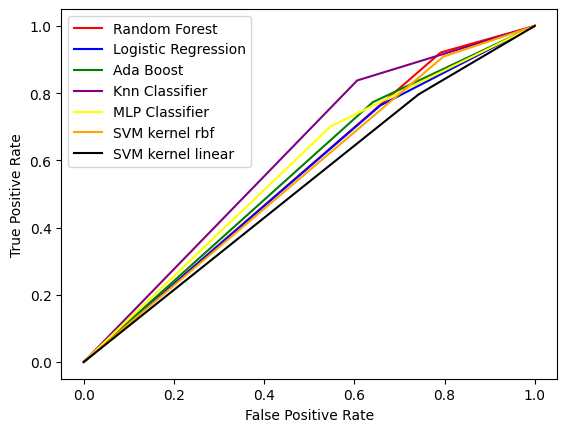

In [16]:
# roc curve and auc

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import time
import pickle



print("Started ")



data = pd.read_csv("./2203_test_dataframe.csv", header=None)
X_test = data.iloc[:, 1:] # features
y_test = data.iloc[:, 0] # target variable


folder_name = "trained_model20k"

def get_performance_metrices(model, index):
    print()
    print("---------------------------------------")
    model_name = list_of_model_names[index]
    print("Model : ", model_name)
    y_pred = model.predict(X_test)
    auc_score = roc_auc_score(y_test, y_pred)
    #Confusion Matrix
    conf_matx = confusion_matrix(y_test, y_pred)
    model_f1_score = f1_score(y_test, y_pred)
    print("Confusion Matrix : ", conf_matx)
    print("Precision Score : ", precision_score(y_test, y_pred))
    print("Recall Score : ", recall_score(y_test, y_pred))
    print("Accuracy Score : ", accuracy_score(y_test, y_pred))
    print("F1 Score : ", model_f1_score)
    # summarize scores
    fpr, tpr, thresholds = roc_curve(y_test, y_pred)
    return {model_name: { "fpr": fpr, "tpr": tpr, "f1-score": model_f1_score, "roc auc": auc_score}}
    
    


def get_model(file_name="radom_forest_model.sav"):
    model = pickle.load(open(f"{folder_name}/{file_name}", "rb"))
    return model


list_of_models = ["radom_forest_model.sav", "logistic_model.sav", "ada_boost_model.sav", 
                  "knn_classifier_model.sav", "mlp_model.sav", "svm_kernel_rbf.sav", "svm_kernel_linear.sav"]

list_of_model_names = ["Random Forest", "Logistic Regression", "Ada Boost", "Knn Classifier", "MLP Classifier", "SVM kernel rbf", "SVM kernel linear"]

list_of_scores = []

for index, model_name in enumerate(list_of_models):
    trained_model = get_model(model_name)
    performance_score = get_performance_metrices(trained_model, index)
    list_of_scores.append(performance_score)
    
        
def plot_roc(fpr, tpr, color="None", label="None"):
    pyplot.plot(fpr, tpr, color, label=label)

colors = ["red", "blue", "green", "purple", "yellow", "orange", "black"]

for indx, score in enumerate(list_of_scores):
    # print(indx, score)
    plot_roc(score[list(score.keys())[0]]["fpr"], score[list(score.keys())[0]]["tpr"], color=colors[indx], label=list(score.keys())[0])
    
# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()

# Save as image
pyplot.savefig(f'{folder_name}/test_roc_auc_curve.svg', format='svg')

# show the plot
pyplot.show()

### 2. Test for trained_model30k

Started 

---------------------------------------
Model :  Random Forest
Confusion Matrix :  [[ 657 2990]
 [ 186 3350]]
Precision Score :  0.5283911671924291
Recall Score :  0.9473981900452488
Accuracy Score :  0.5578449115968258
F1 Score :  0.6784123126771974

---------------------------------------
Model :  Logistic Regression
Confusion Matrix :  [[1410 2237]
 [ 841 2695]]
Precision Score :  0.5464314679643146
Recall Score :  0.7621606334841629
Accuracy Score :  0.5714882361130447
F1 Score :  0.6365139348134151

---------------------------------------
Model :  Ada Boost
Confusion Matrix :  [[1240 2407]
 [ 806 2730]]
Precision Score :  0.5314385828304458
Recall Score :  0.7720588235294118
Accuracy Score :  0.5526938605039677
F1 Score :  0.6295399515738499

---------------------------------------
Model :  Knn Classifier
Confusion Matrix :  [[1416 2231]
 [ 574 2962]]
Precision Score :  0.5703832081648372
Recall Score :  0.8376696832579186
Accuracy Score :  0.6094946401225115
F1 Score : 

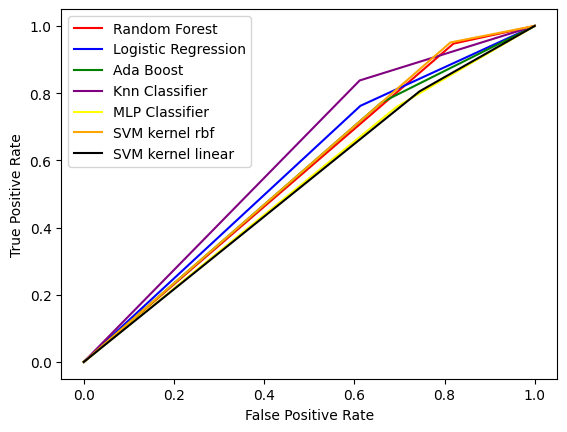

In [17]:
# roc curve and auc

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import time
import pickle



print("Started ")



data = pd.read_csv("./2203_test_dataframe.csv", header=None)
X_test = data.iloc[:, 1:] # features
y_test = data.iloc[:, 0] # target variable


folder_name = "trained_model30k"

def get_performance_metrices(model, index):
    print()
    print("---------------------------------------")
    model_name = list_of_model_names[index]
    print("Model : ", model_name)
    y_pred = model.predict(X_test)
    auc_score = roc_auc_score(y_test, y_pred)
    #Confusion Matrix
    conf_matx = confusion_matrix(y_test, y_pred)
    model_f1_score = f1_score(y_test, y_pred)
    print("Confusion Matrix : ", conf_matx)
    print("Precision Score : ", precision_score(y_test, y_pred))
    print("Recall Score : ", recall_score(y_test, y_pred))
    print("Accuracy Score : ", accuracy_score(y_test, y_pred))
    print("F1 Score : ", model_f1_score)
    # summarize scores
    fpr, tpr, thresholds = roc_curve(y_test, y_pred)
    return {model_name: { "fpr": fpr, "tpr": tpr, "f1-score": model_f1_score, "roc auc": auc_score}}
    
    


def get_model(file_name="radom_forest_model.sav"):
    model = pickle.load(open(f"{folder_name}/{file_name}", "rb"))
    return model


list_of_models = ["radom_forest_model.sav", "logistic_model.sav", "ada_boost_model.sav", 
                  "knn_classifier_model.sav", "mlp_model.sav", "svm_kernel_rbf.sav", "svm_kernel_linear.sav"]

list_of_model_names = ["Random Forest", "Logistic Regression", "Ada Boost", "Knn Classifier", "MLP Classifier", "SVM kernel rbf", "SVM kernel linear"]

list_of_scores = []

for index, model_name in enumerate(list_of_models):
    trained_model = get_model(model_name)
    performance_score = get_performance_metrices(trained_model, index)
    list_of_scores.append(performance_score)
    
        
def plot_roc(fpr, tpr, color="None", label="None"):
    pyplot.plot(fpr, tpr, color, label=label)

colors = ["red", "blue", "green", "purple", "yellow", "orange", "black"]

for indx, score in enumerate(list_of_scores):
    # print(indx, score)
    plot_roc(score[list(score.keys())[0]]["fpr"], score[list(score.keys())[0]]["tpr"], color=colors[indx], label=list(score.keys())[0])
    
# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()

# Save as image
pyplot.savefig(f'{folder_name}/test_roc_auc_curve.svg', format='svg')

# show the plot
pyplot.show()

### 3. Test for trained_model40k

Started 

---------------------------------------
Model :  Random Forest
Confusion Matrix :  [[ 669 2978]
 [ 166 3370]]
Precision Score :  0.5308758664146188
Recall Score :  0.9530542986425339
Accuracy Score :  0.5622998747041626
F1 Score :  0.6819101578308377

---------------------------------------
Model :  Logistic Regression
Confusion Matrix :  [[1395 2252]
 [ 809 2727]]
Precision Score :  0.5477003414340229
Recall Score :  0.771210407239819
Accuracy Score :  0.5738549352638174
F1 Score :  0.6405167351732238

---------------------------------------
Model :  Ada Boost
Confusion Matrix :  [[1222 2425]
 [ 718 2818]]
Precision Score :  0.5374785428189968
Recall Score :  0.7969457013574661
Accuracy Score :  0.5624390923012669
F1 Score :  0.6419865588335801

---------------------------------------
Model :  Knn Classifier
Confusion Matrix :  [[1277 2370]
 [ 498 3038]]
Precision Score :  0.5617603550295858
Recall Score :  0.8591628959276018
Accuracy Score :  0.6007239315049422
F1 Score :  

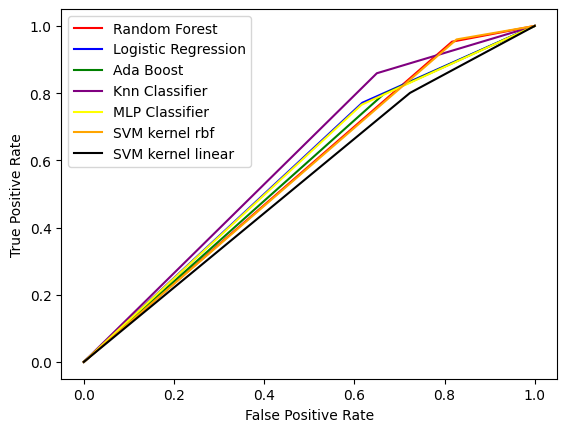

In [18]:
# roc curve and auc

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import time
import pickle



print("Started ")



data = pd.read_csv("./2203_test_dataframe.csv", header=None)
X_test = data.iloc[:, 1:] # features
y_test = data.iloc[:, 0] # target variable


folder_name = "trained_model40k"

def get_performance_metrices(model, index):
    print()
    print("---------------------------------------")
    model_name = list_of_model_names[index]
    print("Model : ", model_name)
    y_pred = model.predict(X_test)
    auc_score = roc_auc_score(y_test, y_pred)
    #Confusion Matrix
    conf_matx = confusion_matrix(y_test, y_pred)
    model_f1_score = f1_score(y_test, y_pred)
    print("Confusion Matrix : ", conf_matx)
    print("Precision Score : ", precision_score(y_test, y_pred))
    print("Recall Score : ", recall_score(y_test, y_pred))
    print("Accuracy Score : ", accuracy_score(y_test, y_pred))
    print("F1 Score : ", model_f1_score)
    # summarize scores
    fpr, tpr, thresholds = roc_curve(y_test, y_pred)
    return {model_name: { "fpr": fpr, "tpr": tpr, "f1-score": model_f1_score, "roc auc": auc_score}}
    
    


def get_model(file_name="radom_forest_model.sav"):
    model = pickle.load(open(f"{folder_name}/{file_name}", "rb"))
    return model


list_of_models = ["radom_forest_model.sav", "logistic_model.sav", "ada_boost_model.sav", 
                  "knn_classifier_model.sav", "mlp_model.sav", "svm_kernel_rbf.sav", "svm_kernel_linear.sav"]

list_of_model_names = ["Random Forest", "Logistic Regression", "Ada Boost", "Knn Classifier", "MLP Classifier", "SVM kernel rbf", "SVM kernel linear"]

list_of_scores = []

for index, model_name in enumerate(list_of_models):
    trained_model = get_model(model_name)
    performance_score = get_performance_metrices(trained_model, index)
    list_of_scores.append(performance_score)
    
        
def plot_roc(fpr, tpr, color="None", label="None"):
    pyplot.plot(fpr, tpr, color, label=label)

colors = ["red", "blue", "green", "purple", "yellow", "orange", "black"]

for indx, score in enumerate(list_of_scores):
    # print(indx, score)
    plot_roc(score[list(score.keys())[0]]["fpr"], score[list(score.keys())[0]]["tpr"], color=colors[indx], label=list(score.keys())[0])
    
# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()

# Save as image
pyplot.savefig(f'{folder_name}/test_roc_auc_curve.svg', format='svg')

# show the plot
pyplot.show()

### 4. Test for trained_model50k

Started 

---------------------------------------
Model :  Random Forest
Confusion Matrix :  [[ 545 3102]
 [ 183 3353]]
Precision Score :  0.519442292796282
Recall Score :  0.9482466063348416
Accuracy Score :  0.5426701935124599
F1 Score :  0.6712040836753077

---------------------------------------
Model :  Logistic Regression
Confusion Matrix :  [[1439 2208]
 [ 785 2751]]
Precision Score :  0.5547489413188142
Recall Score :  0.7779977375565611
Accuracy Score :  0.5833217318669079
F1 Score :  0.6476751030017658

---------------------------------------
Model :  Ada Boost
Confusion Matrix :  [[1305 2342]
 [ 778 2758]]
Precision Score :  0.5407843137254902
Recall Score :  0.7799773755656109
Accuracy Score :  0.5656410970346651
F1 Score :  0.6387216303844372

---------------------------------------
Model :  Knn Classifier
Confusion Matrix :  [[1362 2285]
 [ 503 3033]]
Precision Score :  0.5703271906731854
Recall Score :  0.8577488687782805
Accuracy Score :  0.6118613392732841
F1 Score :  

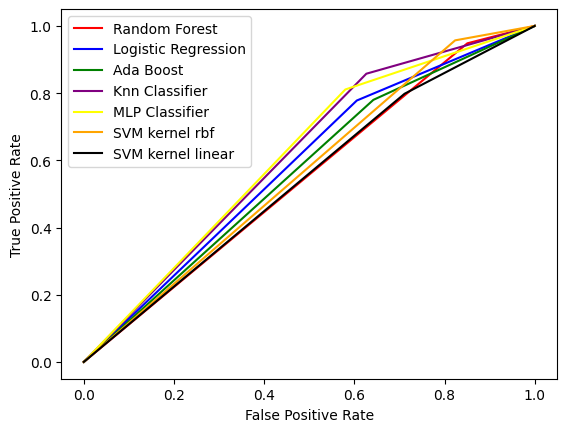

In [19]:
# roc curve and auc

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import time
import pickle



print("Started ")



data = pd.read_csv("./2203_test_dataframe.csv", header=None)
X_test = data.iloc[:, 1:] # features
y_test = data.iloc[:, 0] # target variable


folder_name = "trained_model50k"

def get_performance_metrices(model, index):
    print()
    print("---------------------------------------")
    model_name = list_of_model_names[index]
    print("Model : ", model_name)
    y_pred = model.predict(X_test)
    auc_score = roc_auc_score(y_test, y_pred)
    #Confusion Matrix
    conf_matx = confusion_matrix(y_test, y_pred)
    model_f1_score = f1_score(y_test, y_pred)
    print("Confusion Matrix : ", conf_matx)
    print("Precision Score : ", precision_score(y_test, y_pred))
    print("Recall Score : ", recall_score(y_test, y_pred))
    print("Accuracy Score : ", accuracy_score(y_test, y_pred))
    print("F1 Score : ", model_f1_score)
    # summarize scores
    fpr, tpr, thresholds = roc_curve(y_test, y_pred)
    return {model_name: { "fpr": fpr, "tpr": tpr, "f1-score": model_f1_score, "roc auc": auc_score}}
    
    


def get_model(file_name="radom_forest_model.sav"):
    model = pickle.load(open(f"{folder_name}/{file_name}", "rb"))
    return model


list_of_models = ["radom_forest_model.sav", "logistic_model.sav", "ada_boost_model.sav", 
                  "knn_classifier_model.sav", "mlp_model.sav", "svm_kernel_rbf.sav", "svm_kernel_linear.sav"]

list_of_model_names = ["Random Forest", "Logistic Regression", "Ada Boost", "Knn Classifier", "MLP Classifier", "SVM kernel rbf", "SVM kernel linear"]

list_of_scores = []

for index, model_name in enumerate(list_of_models):
    trained_model = get_model(model_name)
    performance_score = get_performance_metrices(trained_model, index)
    list_of_scores.append(performance_score)
    
        
def plot_roc(fpr, tpr, color="None", label="None"):
    pyplot.plot(fpr, tpr, color, label=label)

colors = ["red", "blue", "green", "purple", "yellow", "orange", "black"]

for indx, score in enumerate(list_of_scores):
    # print(indx, score)
    plot_roc(score[list(score.keys())[0]]["fpr"], score[list(score.keys())[0]]["tpr"], color=colors[indx], label=list(score.keys())[0])
    
# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()

# Save as image
pyplot.savefig(f'{folder_name}/test_roc_auc_curve.svg', format='svg')

# show the plot
pyplot.show()

### 5. Test for trained_model60k

Started 

---------------------------------------
Model :  Random Forest
Confusion Matrix :  [[ 607 3040]
 [ 171 3365]]
Precision Score :  0.5253708040593287
Recall Score :  0.9516402714932126
Accuracy Score :  0.5529722956981763
F1 Score :  0.6769942661704055

---------------------------------------
Model :  Logistic Regression
Confusion Matrix :  [[1465 2182]
 [ 766 2770]]
Precision Score :  0.5593699515347335
Recall Score :  0.7833710407239819
Accuracy Score :  0.5895865237366003
F1 Score :  0.6526861451460886

---------------------------------------
Model :  Ada Boost
Confusion Matrix :  [[1310 2337]
 [ 847 2689]]
Precision Score :  0.5350179068842021
Recall Score :  0.7604638009049773
Accuracy Score :  0.5567311708199917
F1 Score :  0.6281242700303667

---------------------------------------
Model :  Knn Classifier
Confusion Matrix :  [[1335 2312]
 [ 505 3031]]
Precision Score :  0.5672842972113045
Recall Score :  0.857183257918552
Accuracy Score :  0.6078240289572602
F1 Score :  

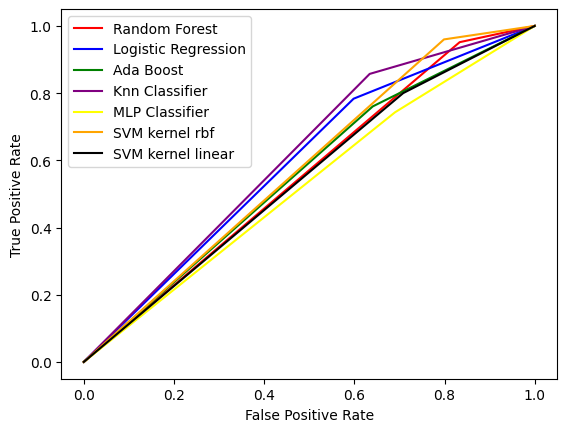

In [20]:
# roc curve and auc

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import time
import pickle



print("Started ")



data = pd.read_csv("./2203_test_dataframe.csv", header=None)
X_test = data.iloc[:, 1:] # features
y_test = data.iloc[:, 0] # target variable


folder_name = "trained_model60k"

def get_performance_metrices(model, index):
    print()
    print("---------------------------------------")
    model_name = list_of_model_names[index]
    print("Model : ", model_name)
    y_pred = model.predict(X_test)
    auc_score = roc_auc_score(y_test, y_pred)
    #Confusion Matrix
    conf_matx = confusion_matrix(y_test, y_pred)
    model_f1_score = f1_score(y_test, y_pred)
    print("Confusion Matrix : ", conf_matx)
    print("Precision Score : ", precision_score(y_test, y_pred))
    print("Recall Score : ", recall_score(y_test, y_pred))
    print("Accuracy Score : ", accuracy_score(y_test, y_pred))
    print("F1 Score : ", model_f1_score)
    # summarize scores
    fpr, tpr, thresholds = roc_curve(y_test, y_pred)
    return {model_name: { "fpr": fpr, "tpr": tpr, "f1-score": model_f1_score, "roc auc": auc_score}}
    
    


def get_model(file_name="radom_forest_model.sav"):
    model = pickle.load(open(f"{folder_name}/{file_name}", "rb"))
    return model


list_of_models = ["radom_forest_model.sav", "logistic_model.sav", "ada_boost_model.sav", 
                  "knn_classifier_model.sav", "mlp_model.sav", "svm_kernel_rbf.sav", "svm_kernel_linear.sav"]

list_of_model_names = ["Random Forest", "Logistic Regression", "Ada Boost", "Knn Classifier", "MLP Classifier", "SVM kernel rbf", "SVM kernel linear"]

list_of_scores = []

for index, model_name in enumerate(list_of_models):
    trained_model = get_model(model_name)
    performance_score = get_performance_metrices(trained_model, index)
    list_of_scores.append(performance_score)
    
        
def plot_roc(fpr, tpr, color="None", label="None"):
    pyplot.plot(fpr, tpr, color, label=label)

colors = ["red", "blue", "green", "purple", "yellow", "orange", "black"]

for indx, score in enumerate(list_of_scores):
    # print(indx, score)
    plot_roc(score[list(score.keys())[0]]["fpr"], score[list(score.keys())[0]]["tpr"], color=colors[indx], label=list(score.keys())[0])
    
# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()

# Save as image
pyplot.savefig(f'{folder_name}/test_roc_auc_curve.svg', format='svg')

# show the plot
pyplot.show()

# Testing the model on data from 2403

Started 

---------------------------------------
Model :  Random Forest
['T', '__abs__', '__add__', '__and__', '__array__', '__array_finalize__', '__array_function__', '__array_interface__', '__array_prepare__', '__array_priority__', '__array_struct__', '__array_ufunc__', '__array_wrap__', '__bool__', '__class__', '__class_getitem__', '__complex__', '__contains__', '__copy__', '__deepcopy__', '__delattr__', '__delitem__', '__dir__', '__divmod__', '__dlpack__', '__dlpack_device__', '__doc__', '__eq__', '__float__', '__floordiv__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__gt__', '__hash__', '__iadd__', '__iand__', '__ifloordiv__', '__ilshift__', '__imatmul__', '__imod__', '__imul__', '__index__', '__init__', '__init_subclass__', '__int__', '__invert__', '__ior__', '__ipow__', '__irshift__', '__isub__', '__iter__', '__itruediv__', '__ixor__', '__le__', '__len__', '__lshift__', '__lt__', '__matmul__', '__mod__', '__mul__', '__ne__', '__neg__', '__new__', '__or__', '__

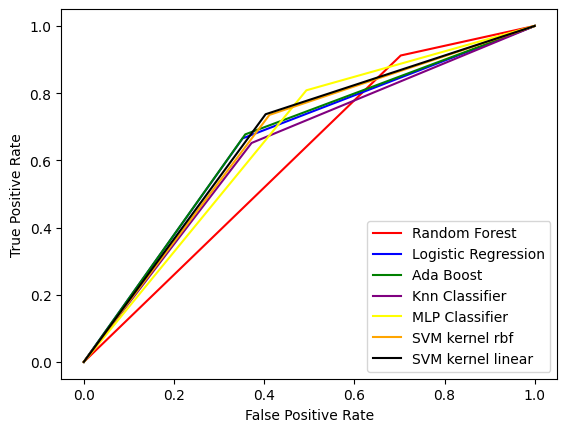

In [7]:
# roc curve and auc

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import time
import pickle



print("Started ")



data = pd.read_csv("./test_dataframe_2403.csv", header=None)
X_test = data.iloc[:, 1:] # features
y_test = data.iloc[:, 0] # target variable


folder_name = "trained_model60k"

def get_performance_metrices(model, index):
    print()
    print("---------------------------------------")
    model_name = list_of_model_names[index]
    print("Model : ", model_name)
    y_pred = model.predict(X_test)
    auc_score = roc_auc_score(y_test, y_pred)
    #Confusion Matrix
    conf_matx = confusion_matrix(y_test, y_pred)
    print(dir(conf_matx))
    model_f1_score = f1_score(y_test, y_pred)
    print("Confusion Matrix : ", conf_matx)
    print("Precision Score : ", precision_score(y_test, y_pred))
    print("Recall Score : ", recall_score(y_test, y_pred))
    print("Accuracy Score : ", accuracy_score(y_test, y_pred))
    print("F1 Score : ", model_f1_score)
    # summarize scores
    fpr, tpr, thresholds = roc_curve(y_test, y_pred)
    return {model_name: { "fpr": fpr, "tpr": tpr, "f1-score": model_f1_score, "roc auc": auc_score}}
    
    


def get_model(file_name="radom_forest_model.sav"):
    model = pickle.load(open(f"{folder_name}/{file_name}", "rb"))
    return model


list_of_models = ["radom_forest_model.sav", "logistic_model.sav", "ada_boost_model.sav", 
                  "knn_classifier_model.sav", "mlp_model.sav", "svm_kernel_rbf.sav", "svm_kernel_linear.sav"]

list_of_model_names = ["Random Forest", "Logistic Regression", "Ada Boost", "Knn Classifier", "MLP Classifier", "SVM kernel rbf", "SVM kernel linear"]

list_of_scores = []

for index, model_name in enumerate(list_of_models):
    trained_model = get_model(model_name)
    performance_score = get_performance_metrices(trained_model, index)
    list_of_scores.append(performance_score)
    
        
def plot_roc(fpr, tpr, color="None", label="None"):
    pyplot.plot(fpr, tpr, color, label=label)

colors = ["red", "blue", "green", "purple", "yellow", "orange", "black"]

for indx, score in enumerate(list_of_scores):
    # print(indx, score)
    plot_roc(score[list(score.keys())[0]]["fpr"], score[list(score.keys())[0]]["tpr"], color=colors[indx], label=list(score.keys())[0])
    
# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()

# Save as image
# pyplot.savefig(f'{folder_name}/test_roc_auc_curve.svg', format='svg')

# show the plot
pyplot.show()

Started 

---------------------------------------
Model :  Random Forest
Confusion Matrix :  [[35579 13438]
 [ 1007 49179]]
Precision Score :  0.7853937429132664
Recall Score :  0.9799346431275655
Accuracy Score :  0.8543894841889862
F1 Score :  0.8719448950825776

---------------------------------------
Model :  Logistic Regression
Confusion Matrix :  [[35017 14000]
 [ 7183 43003]]
Precision Score :  0.7543988912864236
Recall Score :  0.8568724345434982
Accuracy Score :  0.7864681511647833
F1 Score :  0.8023771095914694

---------------------------------------
Model :  Ada Boost
Confusion Matrix :  [[33830 15187]
 [ 6197 43989]]
Precision Score :  0.7433587941057186
Recall Score :  0.8765193480253457
Accuracy Score :  0.7844420027620133
F1 Score :  0.8044659022329512

---------------------------------------
Model :  Knn Classifier
Confusion Matrix :  [[37980 11037]
 [ 4812 45374]]
Precision Score :  0.8043466699757139
Recall Score :  0.9041166859283466
Accuracy Score :  0.840236686390

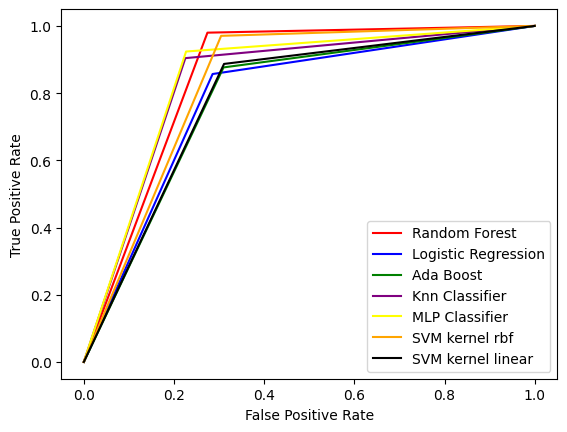

In [2]:
# roc curve and auc

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import time
import pickle



print("Started ")



data = pd.read_csv("./final_dataframe_complete_experiment.csv", header=None)
X_test = data.iloc[:, 1:] # features
y_test = data.iloc[:, 0] # target variable


folder_name = "trained_model60k"

def get_performance_metrices(model, index):
    print()
    print("---------------------------------------")
    model_name = list_of_model_names[index]
    print("Model : ", model_name)
    y_pred = model.predict(X_test)
    auc_score = roc_auc_score(y_test, y_pred)
    #Confusion Matrix
    conf_matx = confusion_matrix(y_test, y_pred)
    model_f1_score = f1_score(y_test, y_pred)
    print("Confusion Matrix : ", conf_matx)
    print("Precision Score : ", precision_score(y_test, y_pred))
    print("Recall Score : ", recall_score(y_test, y_pred))
    print("Accuracy Score : ", accuracy_score(y_test, y_pred))
    print("F1 Score : ", model_f1_score)
    # summarize scores
    fpr, tpr, thresholds = roc_curve(y_test, y_pred)
    return {model_name: { "fpr": fpr, "tpr": tpr, "f1-score": model_f1_score, "roc auc": auc_score}}
    
    


def get_model(file_name="radom_forest_model.sav"):
    model = pickle.load(open(f"{folder_name}/{file_name}", "rb"))
    return model


list_of_models = ["radom_forest_model.sav", "logistic_model.sav", "ada_boost_model.sav", 
                  "knn_classifier_model.sav", "mlp_model.sav", "svm_kernel_rbf.sav", "svm_kernel_linear.sav"]

list_of_model_names = ["Random Forest", "Logistic Regression", "Ada Boost", "Knn Classifier", "MLP Classifier", "SVM kernel rbf", "SVM kernel linear"]

list_of_scores = []

for index, model_name in enumerate(list_of_models):
    trained_model = get_model(model_name)
    performance_score = get_performance_metrices(trained_model, index)
    list_of_scores.append(performance_score)
    
        
def plot_roc(fpr, tpr, color="None", label="None"):
    pyplot.plot(fpr, tpr, color, label=label)

colors = ["red", "blue", "green", "purple", "yellow", "orange", "black"]

for indx, score in enumerate(list_of_scores):
    # print(indx, score)
    plot_roc(score[list(score.keys())[0]]["fpr"], score[list(score.keys())[0]]["tpr"], color=colors[indx], label=list(score.keys())[0])
    
# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()

# Save as image
# pyplot.savefig(f'{folder_name}/test_roc_auc_curve.svg', format='svg')

# show the plot
pyplot.show()